# 01 — Exploratory Data Analysis

First look at the ICU stays table. **Source-parametric**: change the `SOURCE` variable in the next cell to switch between `"synthetic"` (mock data) and `"mimic4"` (credentialed MIMIC-IV 3.1, ~48 K stays after cohort filters).

**Mandatory thesis figures produced here** (saved with the source name as a suffix):
- LoS distribution, raw vs `log1p` — justifies the target transform decision
- Missingness heatmap — supports the data-quality section

**Cohort filters from `README.md` Decisions log** (first stay per patient · age ≥ 18 · ICU LoS ≥ 1 day · exclude ICU deaths) are applied inside `src/data/mimic.py::build_cohort` for MIMIC sources; the last cell verifies the result.

In [1]:
# ── Pick the data source ──
SOURCE = "mimic4"        # "synthetic" | "mimic4"

import sys
from pathlib import Path

# Make src/ importable when running the notebook from notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FIGURES_DIR, TARGET
from src.data.load import load_icu_stays

sns.set_theme(style="whitegrid", context="notebook")

df = load_icu_stays(SOURCE)
STAY_ID = "stay_id" if "stay_id" in df.columns else "icustay_id"

print(f"Source: {SOURCE}")
print(f"Rows: {len(df):,}  |  Cached columns: {df.shape[1]}")
print(f"Note: split_xy() in src/features/build.py expands these to ~152 model features")
print(f"      by adding 40 missing-indicator flags and 2 measurement-count features.")
print(f"      EDA below works on the cached {df.shape[1]} columns; the model sees more.")
df.head()

Source: mimic4
Rows: 48,222  |  Cached columns: 119
Note: split_xy() in src/features/build.py expands these to ~152 model features
      by adding 40 missing-indicator flags and 2 measurement-count features.
      EDA below works on the cached 119 columns; the model sees more.


,subject_id,hadm_id,stay_id,intime,outtime,age,gender,admission_type,race,insurance,...,glucose_slope,hematocrit_slope,hemoglobin_slope,inr_slope,lactate_slope,ph_slope,platelets_slope,potassium_slope,sodium_slope,wbc_slope
0,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17,86,F,EW EMER.,WHITE,Medicare,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00,55,F,EW EMER.,WHITE,Private,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001725,25563031,31205490,2110-04-11 15:52:22,2110-04-12 23:59:56,46,F,EW EMER.,WHITE,Private,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10002013,23581541,39060235,2160-05-18 10:00:53,2160-05-19 17:33:33,57,F,SURGICAL SAME DAY ADMISSION,OTHER,Medicare,...,NaN,0.083062,0.019949,NaN,-0.199513,0.001034,-0.337374,0.056226,-0.295600,-0.078872
4,10002114,27793700,34672098,2162-02-17 23:30:00,2162-02-20 21:16:27,56,M,OBSERVATION ADMIT,UNKNOWN,Medicaid,...,-2.835767,0.057349,-0.005971,NaN,-0.475494,-0.008633,-1.106233,0.053452,0.373881,-0.045472


## 1. Target distribution (LoS in days)

ICU LoS is right-skewed. We compare raw days vs `log1p(days)` to justify the transform used for regression.

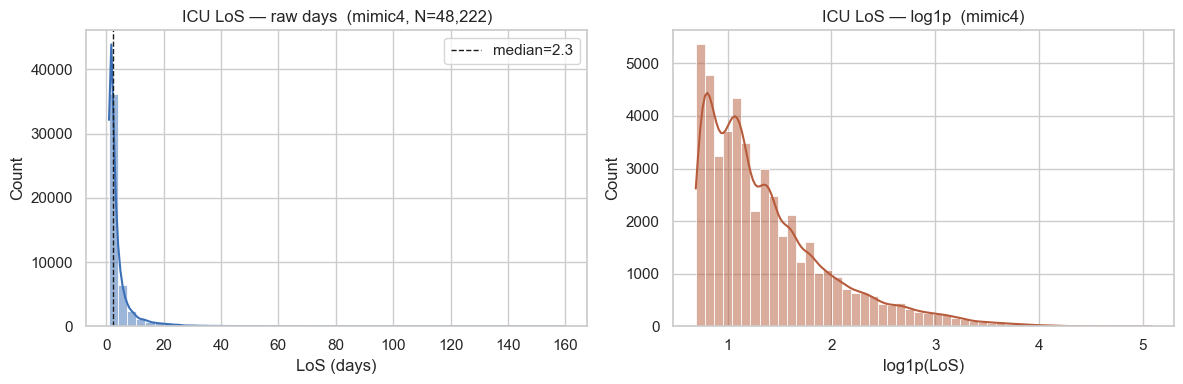

count    48222.000000
mean         4.063534
std          5.406613
min          1.000000
25%          1.511629
50%          2.304091
75%          4.188478
90%          8.348612
95%         13.148885
99%         26.897179
max        159.666806


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=50, kde=True, ax=axes[0], color="#3b6fb6")
axes[0].set_title(f"ICU LoS — raw days  ({SOURCE}, N={len(df):,})")
axes[0].set_xlabel("LoS (days)")
axes[0].axvline(df[TARGET].median(), color="k", ls="--", lw=1, label=f"median={df[TARGET].median():.1f}")
axes[0].legend()

sns.histplot(np.log1p(df[TARGET]), bins=50, kde=True, ax=axes[1], color="#b65b3b")
axes[1].set_title(f"ICU LoS — log1p  ({SOURCE})")
axes[1].set_xlabel("log1p(LoS)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"eda_los_distribution_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

summary = df[TARGET].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(summary.to_string())

In [3]:
# Class balance at two thresholds (main = 7-day clinical convention;
# mean = cohort-mean LoS, used for comparison only)
from src.models.train import LONG_STAY_DAYS, LONG_STAY_DAYS_MEAN

long_7 = (df[TARGET] >= LONG_STAY_DAYS).mean()
long_mean = (df[TARGET] >= LONG_STAY_DAYS_MEAN).mean()

print(f"Threshold = {LONG_STAY_DAYS:.2f} d  (main, clinical 7-day rule):")
print(f"   long  (>={LONG_STAY_DAYS:.0f} d): {long_7:.1%}")
print(f"   short (< {LONG_STAY_DAYS:.0f} d): {1 - long_7:.1%}")
print()
print(f"Threshold = {LONG_STAY_DAYS_MEAN:.2f} d  (cohort mean LoS, comparison only):")
print(f"   long  (>={LONG_STAY_DAYS_MEAN:.2f} d): {long_mean:.1%}")
print(f"   short (< {LONG_STAY_DAYS_MEAN:.2f} d): {1 - long_mean:.1%}")

Threshold = 7.00 d  (main, clinical 7-day rule):
   long  (>=7 d): 12.8%
   short (< 7 d): 87.2%

Threshold = 4.06 d  (cohort mean LoS, comparison only):
   long  (>=4.06 d): 26.2%
   short (< 4.06 d): 73.8%


## 2. Missingness heatmap

Per-column missingness — drives the feature-selection rule (`<30% missing`) for the lab panel.

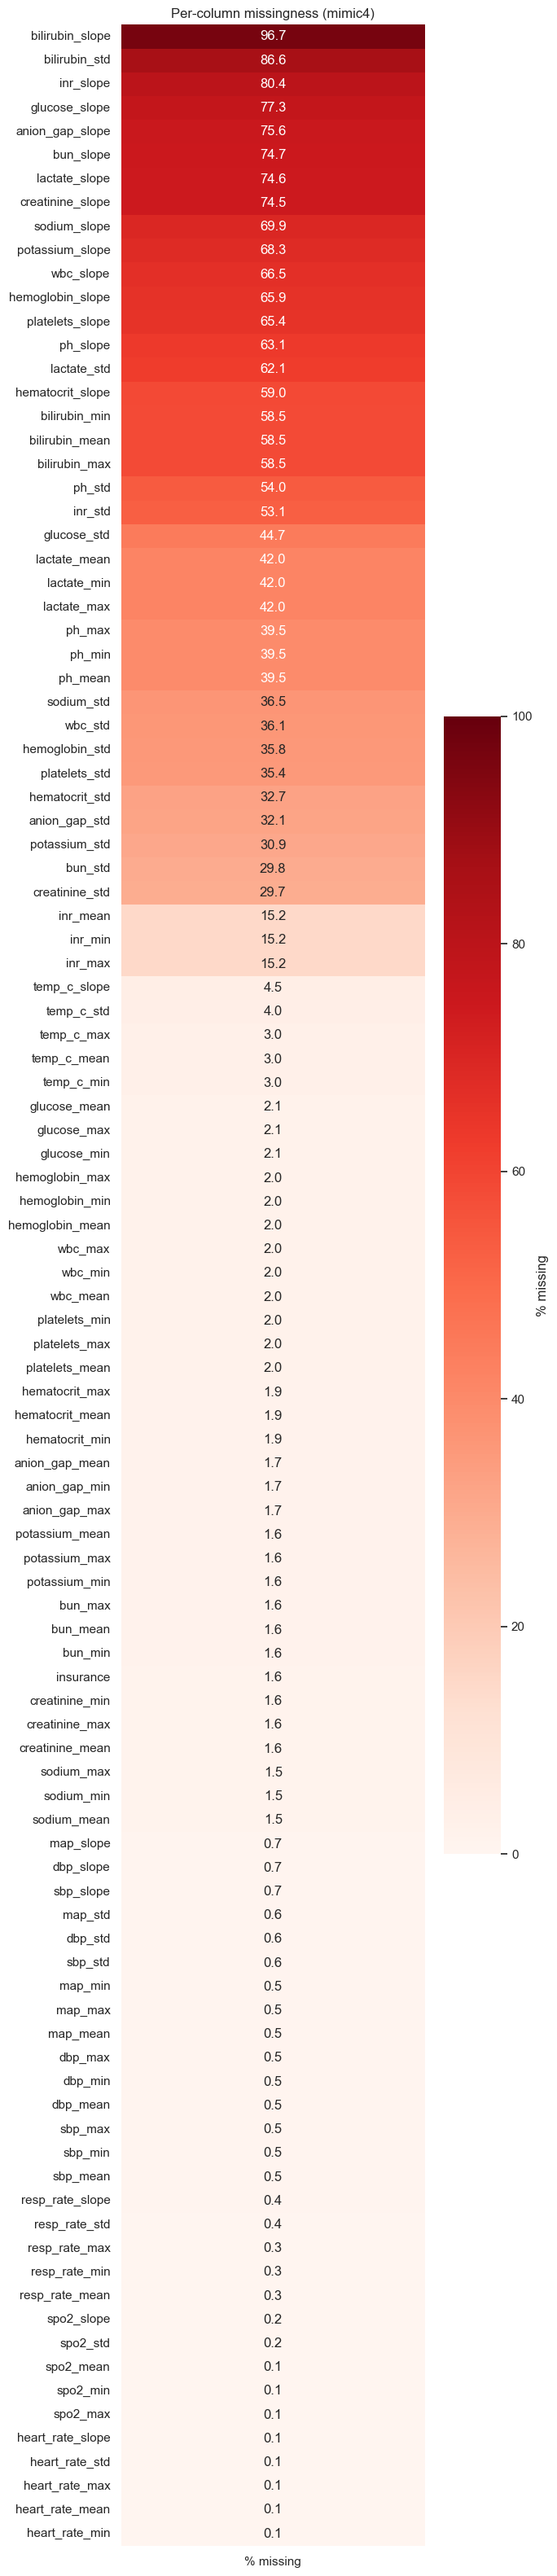

Columns above 30% missing (drop candidates): ['bilirubin_slope', 'bilirubin_std', 'inr_slope', 'glucose_slope', 'anion_gap_slope', 'bun_slope', 'lactate_slope', 'creatinine_slope', 'sodium_slope', 'potassium_slope', 'wbc_slope', 'hemoglobin_slope', 'platelets_slope', 'ph_slope', 'lactate_std', 'hematocrit_slope', 'bilirubin_min', 'bilirubin_mean', 'bilirubin_max', 'ph_std', 'inr_std', 'glucose_std', 'lactate_mean', 'lactate_min', 'lactate_max', 'ph_max', 'ph_min', 'ph_mean', 'sodium_std', 'wbc_std', 'hemoglobin_std', 'platelets_std', 'hematocrit_std', 'anion_gap_std', 'potassium_std']


In [4]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) == 0:
    print("No missing values in any column.")
else:
    fig, ax = plt.subplots(figsize=(7, max(3, 0.30 * len(missing_pct))))
    sns.heatmap(
        missing_pct.to_frame("% missing"),
        annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=100,
        cbar_kws={"label": "% missing"}, ax=ax,
    )
    ax.set_title(f"Per-column missingness ({SOURCE})")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"eda_missingness_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Flag columns that would be dropped under our <30% missing rule
    drop_candidates = missing_pct[missing_pct > 30].index.tolist()
    print(f"Columns above 30% missing (drop candidates): {drop_candidates or '[none]'}")

## 3. Univariate distributions — vitals and labs

Sanity check that values fall in plausible clinical ranges. Outliers here (e.g., HR > 200) usually signal data-entry artifacts in real MIMIC.

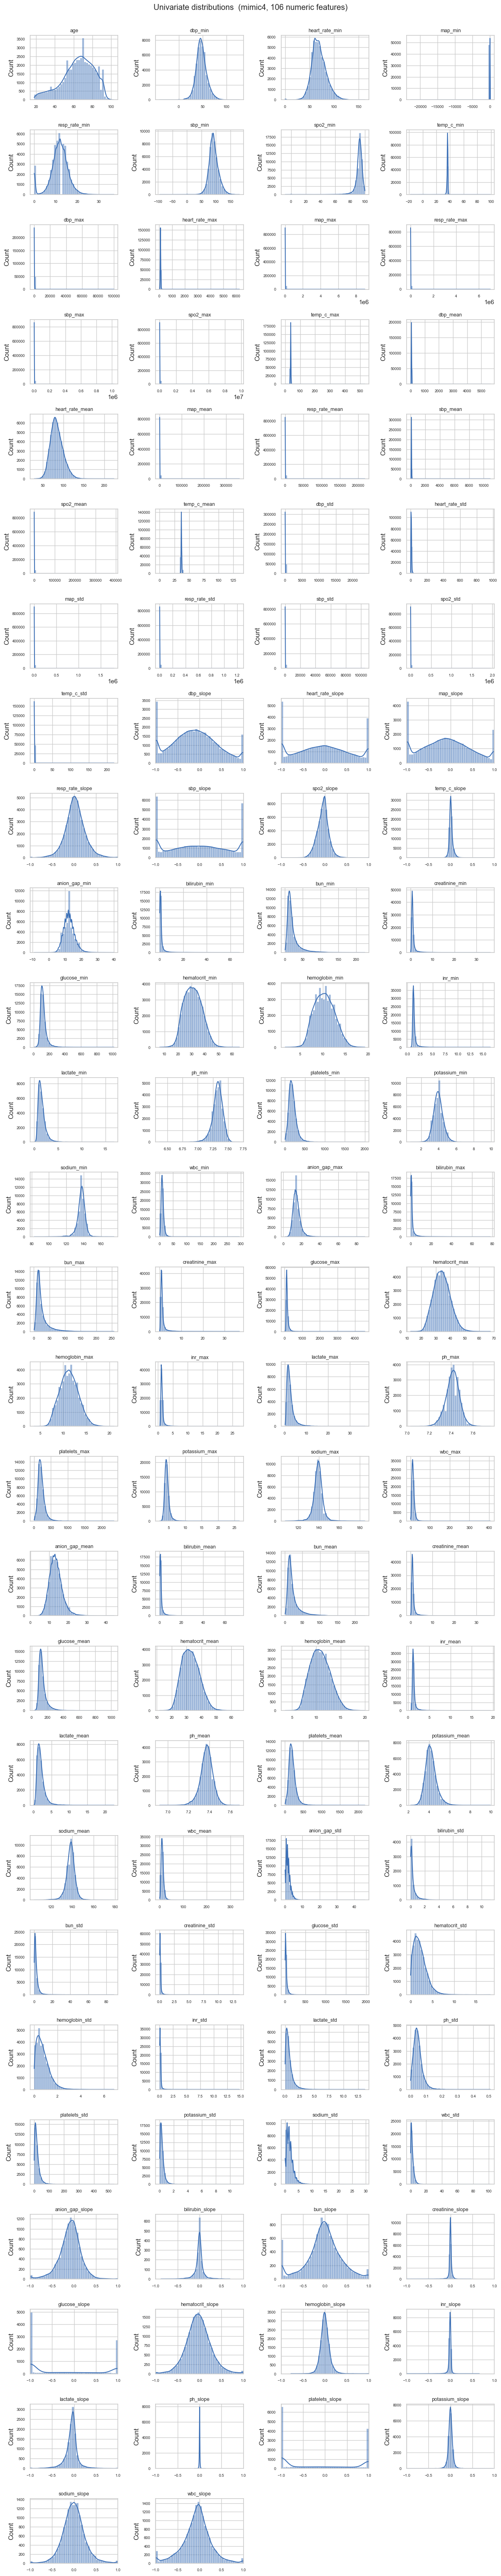

In [5]:
EXCLUDE_ID_LIKE = {"subject_id", "hadm_id", "stay_id", "icustay_id",
                   "hospital_expire_flag", "died_in_icu",
                   TARGET, "has_sepsis"}
numeric_cols = [c for c in df.select_dtypes(include="number").columns
                if c not in EXCLUDE_ID_LIKE]

# Slope features are per-hour value-changes. A handful of stays with extreme
# spikes can pull the raw min/max far past clinically meaningful trend rates,
# making the slope histograms unreadable. Clip the x-axis to [-1, 1] for
# slope columns only; non-slope features keep full data-driven range.
SLOPE_XLIM = (-1, 1)

n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows))
axes_flat = axes.flat if n > 1 else [axes]
for ax, col in zip(axes_flat, numeric_cols):
    series = df[col].dropna()
    is_slope = col.endswith("_slope")
    if is_slope:
        series = series.clip(*SLOPE_XLIM)
    if len(series):
        sns.histplot(series, bins=40, kde=True, ax=ax, color="#3b6fb6")
    if is_slope:
        ax.set_xlim(*SLOPE_XLIM)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
for ax in list(axes.flat)[n:]:
    ax.axis("off")
fig.suptitle(f"Univariate distributions  ({SOURCE}, {n} numeric features)", y=1.001)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"eda_univariate_{SOURCE}.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Categorical breakdowns

LoS by clinically meaningful groups — early signal of which features matter.

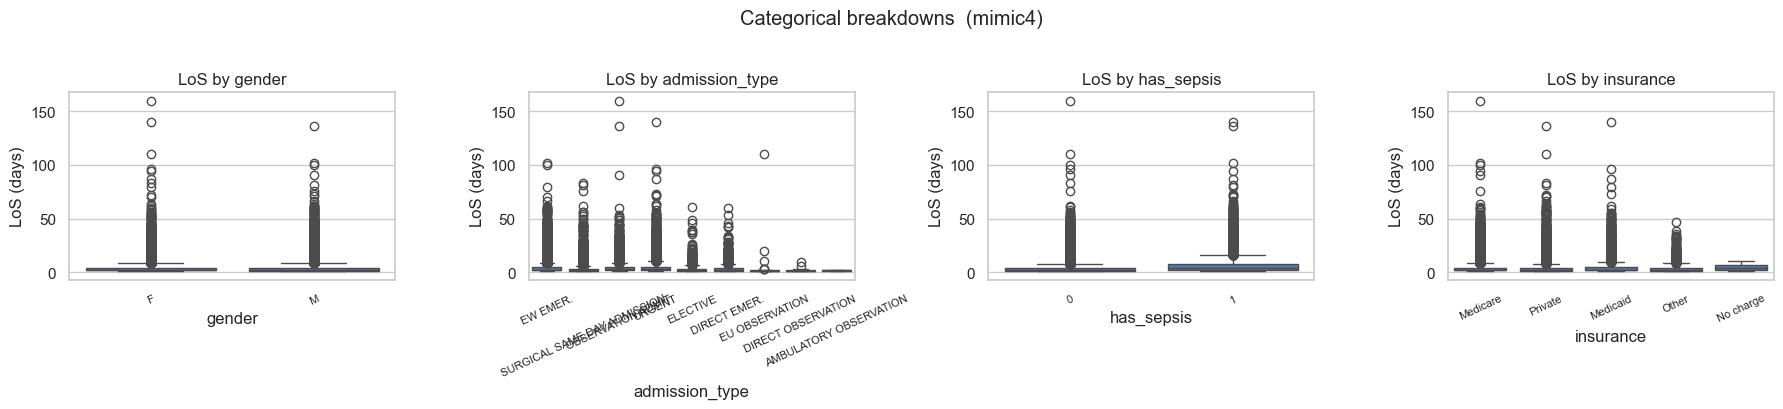

count   mean  median
gender admission_type         has_sepsis insurance                      
F      AMBULATORY OBSERVATION 0          Medicare       2   1.87    1.87
                                         Private        1   1.10    1.10
       DIRECT EMER.           0          Medicaid      78   3.50    2.30
                                         Medicare     319   3.11    2.15
                                         Other         11   3.46    1.95
...                                                   ...    ...     ...
M      URGENT                 1          Medicaid     119  11.34    6.99
                                         Medicare     432   7.39    4.00
                                         Other         16   6.64    3.91
                                         Private      217  10.01    5.69
                                         NaN           18  10.08    5.70

[138 rows x 3 columns]

In [6]:
CANDIDATE_CATS = ["gender", "admission_type", "has_sepsis", "insurance"]
cat_cols = [c for c in CANDIDATE_CATS if c in df.columns]

if not cat_cols:
    print("No categorical columns to plot.")
else:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(4.5 * len(cat_cols), 4))
    if len(cat_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        sns.boxplot(data=df, x=col, y=TARGET, ax=ax)
        ax.set_title(f"LoS by {col}")
        ax.set_ylabel("LoS (days)")
        ax.tick_params(axis="x", rotation=25, labelsize=8)
    fig.suptitle(f"Categorical breakdowns  ({SOURCE})", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"eda_categorical_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()
    display(df.groupby(cat_cols, dropna=False)[TARGET].agg(["count", "mean", "median"]).round(2))

## 5. Correlations

Linear correlations between numeric features and the target. SHAP will tell the real story later, but this is a quick smell test — the **top-20 absolute correlations with target** as a readable bar chart.

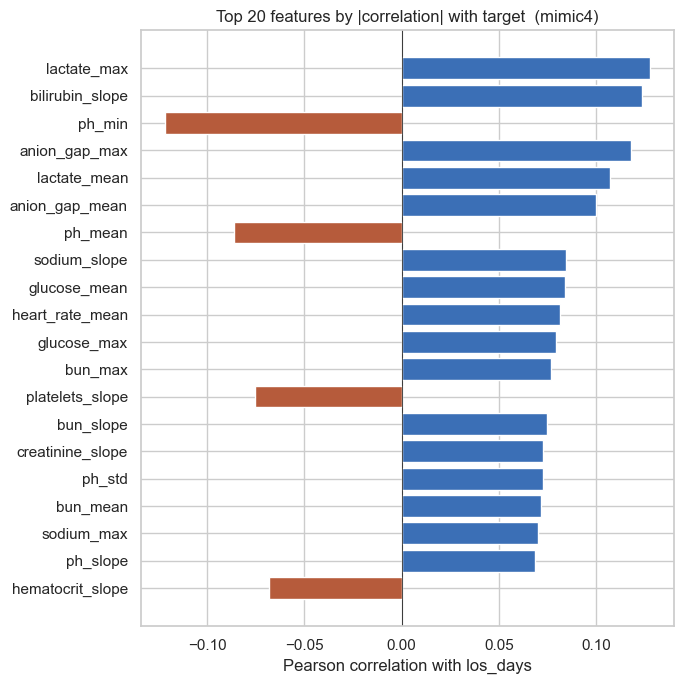

Top 10 absolute correlations with LoS:
lactate_max        0.127603
bilirubin_slope    0.123810
ph_min             0.121521
anion_gap_max      0.118185
lactate_mean       0.107020
anion_gap_mean     0.100179
ph_mean            0.086033
sodium_slope       0.084534
glucose_mean       0.083843
heart_rate_mean    0.081654


In [7]:
corr = df[numeric_cols + [TARGET]].corr(numeric_only=True)
target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)

# (a) Top-20 absolute correlations with the target — readable bar chart
top_k = min(20, len(target_corr))
top = target_corr.head(top_k)[::-1]   # reverse for horizontal bar (largest on top)
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * top_k)))
colors = ["#b65b3b" if v < 0 else "#3b6fb6" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel(f"Pearson correlation with {TARGET}")
ax.set_title(f"Top {top_k} features by |correlation| with target  ({SOURCE})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"eda_top_correlations_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top 10 absolute correlations with LoS:")
print(target_corr.abs().head(10).to_string())

## 6. Descriptive statistics

Publishable summary table of all numeric features: count, mean, std, min, percentiles, max, and missingness. Directly usable in the thesis Methodology section.

In [8]:
desc = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
desc["missing_%"] = df[numeric_cols].isna().mean() * 100
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "95%", "max", "missing_%"]]
desc = desc.round(2)

print(f"Descriptive statistics — {len(numeric_cols)} numeric features  ({SOURCE}, N={len(df):,})")
display(desc)

desc.to_csv(FIGURES_DIR.parent / "tables" / f"descriptive_stats_{SOURCE}.csv")
print(f"\nSaved to reports/tables/descriptive_stats_{SOURCE}.csv")

Descriptive statistics — 106 numeric features  (mimic4, N=48,222)


,count,mean,std,min,25%,50%,75%,95%,max,missing_%
age,48222.0,64.59,16.72,18.00,55.00,66.00,77.00,89.00,103.00,0.00
dbp_min,48002.0,47.47,11.35,-40.00,40.00,47.00,54.00,67.00,127.00,0.46
heart_rate_min,48160.0,69.38,14.87,0.00,60.00,68.00,78.00,96.00,163.00,0.13
map_min,47993.0,59.33,105.28,-22767.00,53.00,60.00,68.00,82.00,138.00,0.47
resp_rate_min,48069.0,11.46,4.36,0.00,10.00,12.00,14.00,18.00,37.00,0.32
...,...,...,...,...,...,...,...,...,...,...
ph_slope,17799.0,0.00,0.01,-0.12,-0.00,0.00,0.01,0.01,0.13,63.09
platelets_slope,16679.0,-0.47,3.05,-35.48,-1.90,-0.38,0.98,4.00,71.68,65.41
potassium_slope,15284.0,-0.00,0.06,-1.25,-0.03,-0.00,0.03,0.08,0.97,68.30
sodium_slope,14535.0,-0.01,0.28,-4.11,-0.16,-0.01,0.13,0.41,9.23,69.86



Saved to reports/tables/descriptive_stats_mimic4.csv


## 7. LoS by age group

ICU length of stay stratified by clinically meaningful age bands (18–40, 40–65, 65–80, 80+). Older patients tend to have longer stays — this is a key confounder and subgroup axis for the fairness analysis in Phase 4.

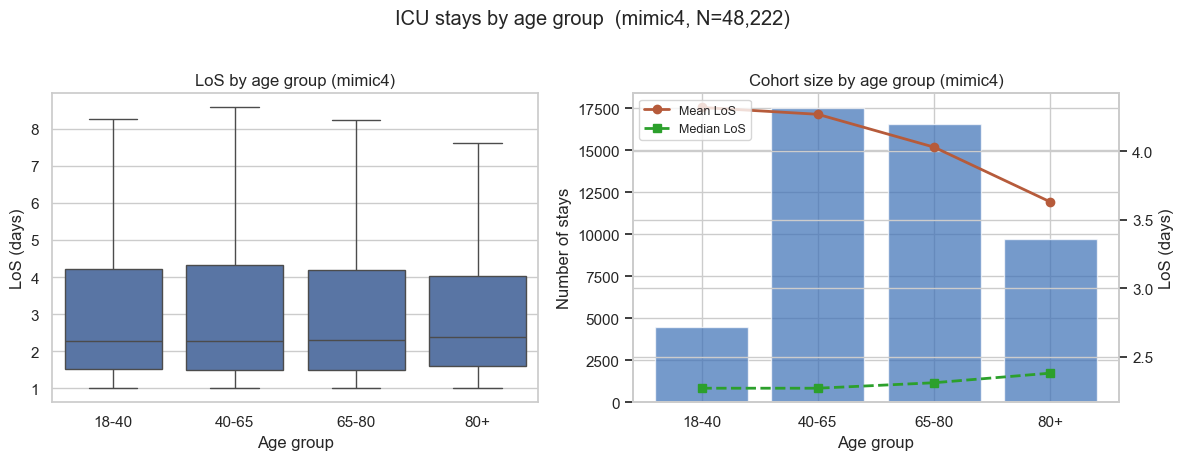

LoS by age group:


,count,mean,median
age_group,,,
18-40,4462,4.32,2.27
40-65,17494,4.27,2.27
65-80,16561,4.03,2.31
80+,9705,3.63,2.38


In [9]:
age_bins = [18, 40, 65, 80, 120]
age_labels = ["18-40", "40-65", "65-80", "80+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Box plot — LoS by age group
sns.boxplot(data=df, x="age_group", y=TARGET, ax=axes[0], showfliers=False)
axes[0].set_title(f"LoS by age group ({SOURCE})")
axes[0].set_xlabel("Age group")
axes[0].set_ylabel("LoS (days)")

# (b) Count + mean table as a bar chart
age_stats = df.groupby("age_group", observed=True)[TARGET].agg(["count", "mean", "median"]).round(2)
ax2 = axes[1]
x = np.arange(len(age_stats))
bars = ax2.bar(x, age_stats["count"], color="#3b6fb6", alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(age_stats.index)
ax2.set_xlabel("Age group")
ax2.set_ylabel("Number of stays")
ax2.set_title(f"Cohort size by age group ({SOURCE})")
ax_twin = ax2.twinx()
ax_twin.plot(x, age_stats["mean"], "o-", color="#b65b3b", lw=2, label="Mean LoS")
ax_twin.plot(x, age_stats["median"], "s--", color="#2ca02c", lw=2, label="Median LoS")
ax_twin.set_ylabel("LoS (days)")
ax_twin.legend(loc="upper left", fontsize=9)

fig.suptitle(f"ICU stays by age group  ({SOURCE}, N={len(df):,})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"eda_age_group_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

print("LoS by age group:")
display(age_stats)

df = df.drop(columns=["age_group"])

## 8. Cohort filter sanity check

For MIMIC sources, cohort filters are already applied inside `src/data/mimic.py::build_cohort()` (first stay / age >= 18 / LoS >= 1 / exclude ICU deaths). This cell verifies each filter passes 100 %.

In [10]:
def cohort_check(df: pd.DataFrame, stay_id_col: str) -> None:
    """Report what fraction of rows would pass each cohort filter.
    On MIMIC sources the filters are already applied, so each check should be 100 %."""
    total = len(df)
    print(f"Rows in dataset: {total:,}\n")

    first_stay = df.groupby("subject_id")[stay_id_col].transform("min") == df[stay_id_col]
    print(f"first stay per patient   : {first_stay.sum():>6,} / {total:,} ({first_stay.mean():.0%})")

    if "age" in df.columns:
        ok = df["age"] >= 18
        print(f"age >= 18                : {ok.sum():>6,} / {total:,} ({ok.mean():.0%})")

    ok = df[TARGET] >= 1.0
    print(f"LoS >= 1 day             : {ok.sum():>6,} / {total:,} ({ok.mean():.0%})")

    if "died_in_icu" in df.columns:
        ok = df["died_in_icu"] == 0
        print(f"died_in_icu == 0         : {ok.sum():>6,} / {total:,} ({ok.mean():.0%})")

cohort_check(df, STAY_ID)

Rows in dataset: 48,222

first stay per patient   : 48,222 / 48,222 (100%)
age >= 18                : 48,222 / 48,222 (100%)
LoS >= 1 day             : 48,222 / 48,222 (100%)
died_in_icu == 0         : 48,222 / 48,222 (100%)
